Loading data...
Training Shape: (2155, 17)
Validation Shape: (462, 17)
Training Logistic Regression...
Predicting on Validation set...

Baseline Metrics:
{
    "model_name": "Logistic Regression (Baseline)",
    "accuracy": 0.6861471861471862,
    "precision": 0.5766871165644172,
    "recall": 0.5529411764705883,
    "f1_score": 0.5645645645645646,
    "roc_auc": 0.7112006446414183
}
Metrics saved to /Users/maneeshkoti/Documents/ecommerce-churn-prediction/models/baseline_metrics.json
Model saved to /Users/maneeshkoti/Documents/ecommerce-churn-prediction/models/baseline_model.pkl
Confusion matrix saved to /Users/maneeshkoti/Documents/ecommerce-churn-prediction/visualizations/baseline_confusion_matrix.png


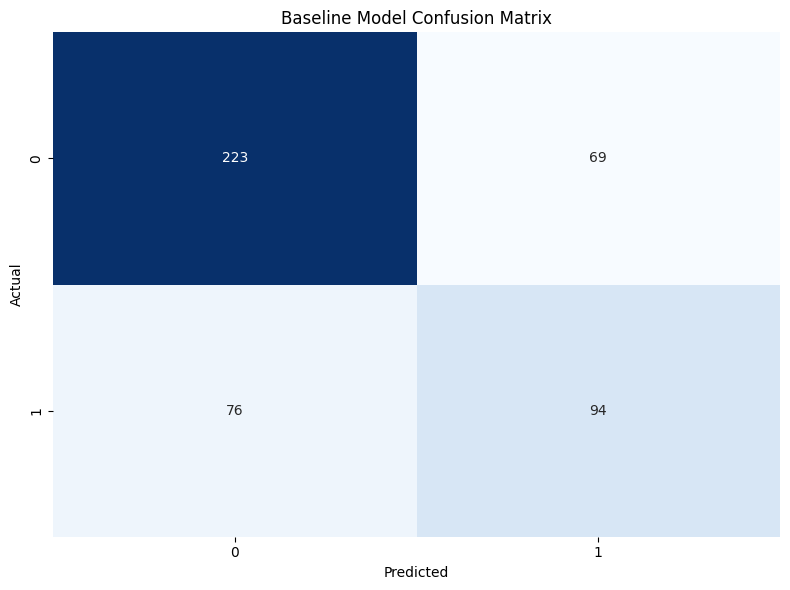

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- CONFIGURATION ---
# Paths (Adjusted for running from project root or notebooks dir)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.getcwd().endswith('notebooks') else os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
VIS_DIR = os.path.join(PROJECT_ROOT, 'visualizations')

# Ensure directories exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# 1. Load Prepared Data
print("Loading data...")
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv')).values.ravel()

X_val = pd.read_csv(os.path.join(DATA_DIR, 'X_val.csv'))
y_val = pd.read_csv(os.path.join(DATA_DIR, 'y_val.csv')).values.ravel()

print(f"Training Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")

# 2. Train Baseline Model (Logistic Regression)
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 3. Predictions
print("Predicting on Validation set...")
y_pred = lr_model.predict(X_val)
y_pred_proba = lr_model.predict_proba(X_val)[:, 1]

# 4. Calculate Metrics
metrics = {
    "model_name": "Logistic Regression (Baseline)",
    "accuracy": float(accuracy_score(y_val, y_pred)),
    "precision": float(precision_score(y_val, y_pred)),
    "recall": float(recall_score(y_val, y_pred)),
    "f1_score": float(f1_score(y_val, y_pred)),
    "roc_auc": float(roc_auc_score(y_val, y_pred_proba))
}

print("\nBaseline Metrics:")
print(json.dumps(metrics, indent=4))

# 5. Save Artifacts

# Save Metrics JSON
metrics_path = os.path.join(MODELS_DIR, 'baseline_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {metrics_path}")

# Save Model
model_path = os.path.join(MODELS_DIR, 'baseline_model.pkl')
joblib.dump(lr_model, model_path)
print(f"Model saved to {model_path}")

# 6. Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

# Save Plot
plot_path = os.path.join(VIS_DIR, 'baseline_confusion_matrix.png')
plt.savefig(plot_path)
print(f"Confusion matrix saved to {plot_path}")
plt.show()